In [ ]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import json
import pandas as pd
import torch
import shutil
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import types
from torchvision.models.resnet import Bottleneck

RESULTS_DIR = Path("../outputs")
RESULTS_DIR.mkdir(exist_ok=True)

# utils/file_utils.py

import Path

def save_log(out_dir, filename, text):


In [16]:
!wget -q https://raw.githubusercontent.com/TayyabWaseem/vision-representations-study/main/utils/file_utils.py -O file_utils.py
!wget -q https://raw.githubusercontent.com/TayyabWaseem/vision-representations-study/main/utils/model_utils.py -O model_utils.py

import model_utils
print(dir(model_utils))
import file_utils

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__']


In [2]:
%config Completer.use_jedi = False

In [3]:
# plt.savefig(RESULTS_DIR / "resnet_tsne.png") ht")

# with open(RESULTS_DIR / "log.txt", "a") as f:
#     f.write(f"ResNet baseline val acc: {val_acc}\n")

# df.to_csv(RESULTS_DIR / "logs" / "clip_prompt_comparison.csv", index=False)

# shutil.make_archive("/kaggle/working/results", "zip", OUT)

## Step 1: Baseline Setup

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 177MB/s] 
100%|██████████| 170M/170M [18:08<00:00, 157kB/s] 


cuda
Epoch 1/5 - Avg Loss: 0.6993 - Val Acc: 83.49%
Epoch 2/5 - Avg Loss: 0.4907 - Val Acc: 84.52%
Epoch 3/5 - Avg Loss: 0.4488 - Val Acc: 84.73%
Epoch 4/5 - Avg Loss: 0.4209 - Val Acc: 85.24%
Epoch 5/5 - Avg Loss: 0.4072 - Val Acc: 84.89%


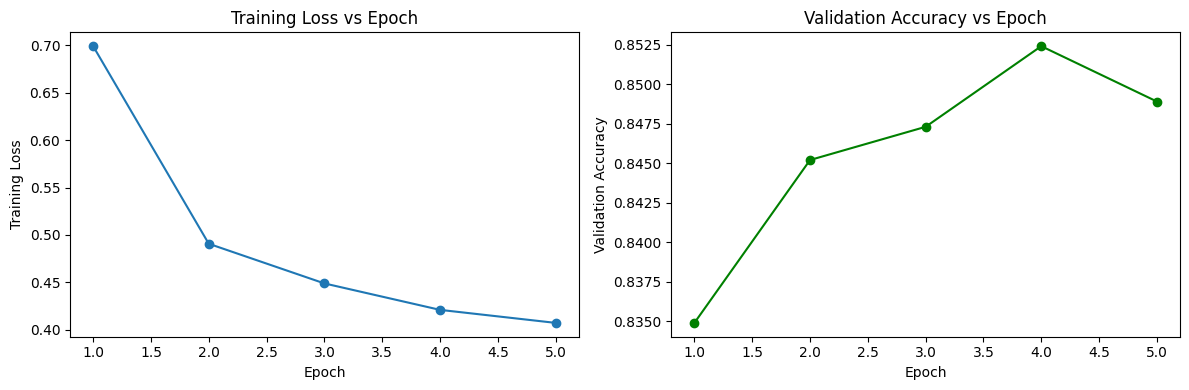

In [3]:
# (a) Use a pre-trained ResNet-152 from PyTorch.
# IMAGENET1K_V2 provides state-of-the-art pre-trained weights for this architecture
# It is the newer version

from torchvision.models import resnet152, ResNet152_Weights
model = resnet152(weights=ResNet152_Weights.IMAGENET1K_V2, progress=True)

# (b) Replace the final classification layer to match a smaller dataset such as CIFAR-10.
# If we print the model, at the end of the output we get:
# (fc): Linear(in_features=2048, out_features=1000, bias=True)
# This shows that the final fully-connected layer maps from 2048 -> 1000
# To match a CIFAR-10 dataset, it needs to map from 2048 -> 10
# fc layer -> nn.Linear() layer
# No need to hardcode 2048

model.fc = nn.Linear(model.fc.in_features, 10)

# (c) Train only the classification head while freezing the rest of the backbone.
# Freeze all model parameters first
# Then unfreeze model.fc parameters
# Then run the optimizer

for param in model.parameters():
    param.requires_grad = False
    
for param in model.fc.parameters():
    param.requires_grad = True

# for name, param in model.named_parameters():  # for testing if it worked
#     print(name, param.requires_grad)

# (d) Record training and validation performance for a few epochs.
# We should plot a graph here comparing the training and performance with epochs
# Let's go with 5 epochs for good measure
# Have to load CIFAR-10 first
# Use Adam's Optimizer due to quicker convergence
# Use CrossEntropyLoss because it's multi-class classification

# -------- data --------
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_set = torchvision.datasets.CIFAR10(root='../data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=2)

test_set = torchvision.datasets.CIFAR10(root='../data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False, num_workers=2)

# -------- cuda --------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

# --------- optimizer and loss ---------
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# -------- training helper --------
def evaluate(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

training_history = []
epochs = 5

# --------- training loop ---------
for epoch in range(1,epochs+1): # 5 epochs
    model.train()
    current_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        current_loss += loss.item()
        
    avg_loss = current_loss / len(train_loader)
    val_acc = evaluate(test_loader)
    print(f"Epoch {epoch}/{epochs} - Avg Loss: {avg_loss:.4f} - Val Acc: {val_acc*100:.2f}%")
    training_history.append((epoch, avg_loss, val_acc))

# -------- diagrams --------
epochs_list = [h[0] for h in training_history]
loss_list   = [h[1] for h in training_history]
val_acc_list = [h[2] for h in training_history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(epochs_list, loss_list, marker='o')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("Training Loss vs Epoch")

# Validation accuracy curve
axes[1].plot(epochs_list, val_acc_list, marker='o', color='green')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_title("Validation Accuracy vs Epoch")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "resnet_baseline_train_val_curve.png", dpi=150)
plt.show()

## Step 2: Residual Connections in Practice

In [ ]:
# (a) Disable skip connections in a few selected residual blocks and re-train the modified network head.
# Residual function: F(x) = H(x) - x ---> Output = F(x) + x
# Read documentation for the original forward pass in Bottleneck.forward()
# Write a replacement forward() pass with no skip connections

def forward_no_skip(self, x):
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)

    out = self.conv3(out)
    out = self.bn3(out)

    # NOTE: Skip connection removed entirely: no identity/downsample branch is computed or added
    out = self.relu(out)

    return out

# Creating a new fresh model to compare against the baseline model
# Change final layer out_features
# Then do the similar (c) freezing and unfreezing step
# Selecting a few blocks to test it on
# Create Utility functions

model_no_skip = resnet152(weights=ResNet152_Weights.IMAGENET1K_V2)
model_no_skip.fc = nn.Linear(model_no_skip.fc.in_features, 10)
model_no_skip = model_utils.freeze_backbone_except(model_no_skip)

blocks_to_modify = [
    model_no_skip.layer2[0],
    model_no_skip.layer3[0],
    model_no_skip.layer4[0],
]

for block in blocks_to_modify:
    block.forward = types.MethodType(forward_no_skip, block)

model_no_skip = model_no_skip.to(device)
print("Modified blocks:", [b for b in blocks_to_modify])

# (b) Compare training dynamics and validation accuracy with the baseline

optimizer_no_skip = torch.optim.Adam(model_no_skip.fc.parameters(), lr=0.001)
epochs = 5

v2_training_history = model_utils.train_model(model_no_skip, train_loader, test_loader, optimizer_no_skip, criterion, device, epochs=epochs)

# -------- diagrams --------
epochs_list = [h[0] for h in training_history]
loss_list   = [h[1] for h in training_history]
val_acc_list = [h[2] for h in training_history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(epochs_list, loss_list, marker='o')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("Training Loss vs Epoch")

# Validation accuracy curve
axes[1].plot(epochs_list, val_acc_list, marker='o', color='green')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_title("Validation Accuracy vs Epoch")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "resnet_no_skip_train_val_curve.png", dpi=150)
plt.show()